# Лекция 2. Агент, среда, награда, политика. Строим свою среду

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IlyaChichkanov/Reinforcement-learning/blob/main/02-environments/lecture/lecture.ipynb)

**Цели лекции**

1. Научиться раскладывать любую задачу на агента, среду, наблюдение, действие, награду и политику — и понимать, где между ними граница.
2. Понимать, как устроена награда: разреженная и плотная, зачем нужен shaping и как им себе навредить.
3. Уметь написать собственную среду в Gymnasium, проверить её, обернуть и запустить на ней алгоритм из недели 1.

На прошлой лекции мы пользовались готовыми средами. Сегодня откроем капот: посмотрим, что такое среда с точки зрения кода, напишем свою с нуля и научим на ней агента. К концу пары у вас будет шаблон, из которого получается среда для любой задачи с дискретными состояниями — именно это понадобится в домашнем задании и в проектах.

**План и хронометраж (одна пара, 90 минут)**

| | Раздел | Минут |
|---|---|---|
| 1 | Повторение: цикл агент–среда и что мы уже умеем | 5 |
| 2 | Агент и среда: где проходит граница | 6 |
| 3 | Наблюдение и состояние: когда агент видит не всё | 10 |
| 4 | Действия: дискретные, непрерывные, составные | 7 |
| 5 | Награда: разреженная, плотная, shaping и типичные ошибки | 12 |
| 6 | Политика: детерминированная и стохастическая, табличная и параметрическая | 6 |
| 7 | Устройство среды в Gymnasium: `gym.Env`, `spaces`, `reset`, `step` | 8 |
| 8 | Строим свою среду: GridWorld с препятствиями | 12 |
| 9 | Обёртки: изменяем среду, не трогая её код; три награды и одна ловушка | 14 |
| 10 | Воспроизводимость, векторные среды, регистрация | 5 |
| 11 | Зоопарк сред: куда идти за задачами | 📖 дома |
| 12 | Итоги | 5 |

Все код-ячейки выполняются на CPU за секунды; тяжелее всего раздел 9 (около минуты).

Пометки в заголовках: **📖 дома** — материал для самостоятельного чтения, на лекции можно пропустить; **⏱ если есть время** — резерв.

In [1]:
# Если ноутбук открыт в Google Colab: ставим недостающие пакеты. Локально (после uv sync) ячейка ничего не делает.
import importlib.util, subprocess, sys
if importlib.util.find_spec("gymnasium") is None or importlib.util.find_spec("pygame") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gymnasium[classic-control]"], check=True)

In [2]:
# Служебный код для картинок: запустить и не читать. Содержательный код начинается со следующего раздела.
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from matplotlib import animation
from IPython.display import HTML, display

def show_frames(frames, title="", interval=250, width=3.0):
    """Кадры среды -> анимация в ноутбуке (видна при запуске; в превью на GitHub показывается только первый кадр)."""
    h, w = frames[0].shape[:2]
    fig, ax = plt.subplots(figsize=(width, width * h / w))
    ax.axis("off"); ax.set_title(title, fontsize=10)
    im = ax.imshow(frames[0])
    plt.close(fig)
    anim = animation.FuncAnimation(fig, lambda i: (im.set_data(frames[i]),),
                                   frames=len(frames), interval=interval, blit=True)
    return HTML(anim.to_jshtml(default_mode="loop"))

def show_strip(frames, title="", n=6, width=16):
    """Несколько кадров эпизода в ряд: статичная картинка, видна и в превью."""
    idx = np.linspace(0, len(frames) - 1, n).astype(int)
    fig, axes = plt.subplots(1, n, figsize=(width, width / n * frames[0].shape[0] / frames[0].shape[1] + 0.4))
    for ax, i in zip(axes, idx):
        ax.imshow(frames[i]); ax.set_title(f"t = {i}", fontsize=9); ax.axis("off")
    plt.suptitle(title); plt.show()

def rollout_frames(env, policy, max_steps=50, seed=0):
    """Эпизод в среде с render_mode='rgb_array': кадры и суммарная награда. policy(obs) -> action."""
    obs, _ = env.reset(seed=seed)
    frames, total = [env.render()], 0.0
    for _ in range(max_steps):
        obs, r, terminated, truncated, _ = env.step(policy(obs))
        frames.append(env.render()); total += r
        if terminated or truncated:
            break
    return frames, total

def show_policy(env, policy):
    """Самое вероятное действие в каждой клетке GridWorld — стрелками."""
    for r in range(env.n_rows):
        print("  " + " ".join(env.layout[r][c] if env.layout[r][c] in "#G"
                              else env.ARROWS[int(np.argmax(policy[r * env.n_cols + c]))]
                              for c in range(env.n_cols)))

## 1. Повторение: что мы уже умеем

![loop](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/agent_env_loop.png)

На прошлой неделе мы договорились о словаре: **агент** принимает решения, **среда** отвечает на них наградой и новым состоянием, **политика** $\pi(a \mid s)$ — правило выбора действия, **эпизод** — одна траектория до терминального состояния, **return** $G = \sum_t \gamma^t R_t$ — то, что агент максимизирует. Формально всё это упаковано в **MDP** $\langle \mathcal{S}, \mathcal{A}, P, R, \gamma \rangle$.

И у нас уже есть рабочий алгоритм — метод Cross-Entropy: сыграть много эпизодов, отобрать лучшие, чаще повторять действия из них. Он ничего не знает про устройство среды, ему нужно только `reset()` и `step()`. Сегодня мы посмотрим на среду с другой стороны — со стороны того, кто её **пишет**.

Вопрос залу: вы придумали задачу и хотите решить её с помощью RL. С чего начать — с выбора алгоритма или со среды? Ответ: со среды. Пока не написана среда, алгоритм не на чем запускать; а половина «неудач RL» на практике — это плохо спроектированные наблюдения и награда, а не плохой алгоритм.

### Разминка: разложите задачу на части

Прежде чем идти дальше, потренируемся на трёх задачах: что здесь **агент**, что **среда**, что агент **видит**, что **делает** и за что ему **платят**. Ответы спрятаны, сначала подумайте сами.

**Робот-пылесос.**

<details>
<summary>Разбор</summary>

Агент — программа управления. Среда — комната, мебель, сам корпус робота с моторами и батареей. Наблюдение — датчики столкновений, лидар или карта, уровень заряда. Действия — скорость колёс (непрерывные) или «вперёд / поворот / на базу» (дискретные). Награда — убранная площадь минус штраф за время и за разряд батареи до нуля. Эпизод — одна уборка.

</details>

**Лента рекомендаций.**

<details>
<summary>Разбор</summary>

Агент — ранжировщик. Среда — пользователь (он «часть среды»: мы не управляем его вкусами) и каталог. Наблюдение — история просмотров, время суток, контекст. Действие — какие $k$ карточек показать (составное, огромное дискретное пространство). Награда — клик, время просмотра, а лучше долгосрочное удержание: за «кликбейт» агент получает сиюминутную награду и теряет пользователя через месяц. Эпизод — сессия или вся история пользователя.

</details>

**Торговый бот.**

<details>
<summary>Разбор</summary>

Агент — стратегия. Среда — рынок, все остальные участники, комиссии и задержки исполнения. Наблюдение — стакан, история цен, наш портфель. Действие — «купить / продать / ждать» или доля портфеля (непрерывное). Награда — изменение стоимости портфеля с учётом риска. Ловушка: среда нестационарна и почти не наблюдаема, а наши сделки меняют цену — это одна из самых трудных постановок для RL.

</details>

## 2. Агент и среда: где проходит граница

<img src="https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/ref/agent_env_dog.png" width="260"> <img src="https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/ref/agent_env_brain.png" width="260">

Две картинки одного цикла: дрессировщик и собака, мозг и мир. В обеих не сразу ясно, где кончается агент и начинается среда: тело собаки — часть агента или среды? Правило ниже отвечает и на это.

Правило простое: **агент — это ровно то, что мы обучаем; среда — всё остальное.** Из него следуют неочевидные вещи.

* **Соперник — часть среды.** В шахматах ходы противника для нашего агента — это стохастические переходы среды. Если соперник тоже учится, среда меняется по ходу обучения (нестационарность) — этим займёмся на неделе 15.
* **Тело робота — часть среды.** Агент — это контроллер, выдающий токи на моторы. Суставы, батарея, задержки датчиков — среда. Поэтому «тот же агент» на другом роботе — другая задача.
* **Интерфейс — часть среды.** Если агент видит игру через 4 кадра, а не через внутреннее состояние движка, у него другая среда, чем у агента с доступом к памяти игры. Разработчик среды решает, что показать.
* **Награда приходит извне.** Агент не может изменить функцию награды — иначе он просто назначит себе бесконечность. Награду задаёт тот, кто ставит задачу (мы), и она живёт в среде.

Практический вывод: **граница агент/среда — это проектное решение**, и сегодня мы будем принимать такие решения сами. Первое из них — что агент видит.

> **Факт.** В DeepMind при обучении агента играть в StarCraft II (AlphaStar) долго спорили, что считать «честным» наблюдением: полная карта из памяти игры или только то, что видит камера человека. Итоговая версия смотрела через камеру и была ограничена в числе действий в минуту — иначе сравнение с людьми теряло смысл. Граница агент/среда определила саму постановку задачи.
> **Факт.** В Dota 2 у OpenAI Five на каждом шаге от восьми до восьмидесяти тысяч допустимых действий (что сделать, на кого, куда). Часть из них в текущем состоянии бессмысленна, и среда сообщает агенту **маску** допустимых действий — об этом в разделе 4. Как устроено действие в игре, подробно описано в [статье OpenAI](https://arxiv.org/abs/1912.06680), раздел «Action space».

## 3. Наблюдение и состояние: когда агент видит не всё

На прошлой лекции мы считали, что агент видит **состояние** $S_t$ — всё, что нужно для решения. На практике агент видит **наблюдение** $O_t$, и оно часто беднее:

* покер: карты соперника скрыты;
* стратегия с туманом войны: видна только часть карты;
* робот с камерой: не видит, что у него за спиной;
* одна картинка из игры: не видно, куда летит мяч.

![pomdp](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/observation_vs_state.png)

Задача, где наблюдение не равно состоянию, называется **частично наблюдаемой** (POMDP — Partially Observable MDP). Строгая теория POMDP сложна, но на практике работают два простых приёма:

1. **Добавить историю в наблюдение.** Стек из последних $k$ кадров (так делает DQN в Atari), разность двух последних наблюдений, последние $k$ действий.
2. **Дать агенту память.** Рекуррентная сеть внутри политики (неделя 10).

> **Факт.** DQN на Atari (2015) подаёт в сеть не один кадр, а **четыре последних**: по одному кадру не понять, куда летит мяч в Breakout. Это самое массовое применение приёма 1 — и стандартная обёртка `FrameStackObservation` в Gymnasium.

Убедимся на CartPole, что наблюдение имеет значение. Наша эвристика с прошлой лекции смотрела на угловую скорость шеста $\dot\theta$. Отнимем её у агента.

In [3]:
def evaluate(policy, n_episodes=30):
    """policy(obs, prev_obs) -> action. Средний return по эпизодам."""
    env = gym.make("CartPole-v1")
    returns = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=ep)
        prev, total = obs.copy(), 0.0
        while True:
            a = policy(obs, prev)
            prev = obs.copy()
            obs, r, terminated, truncated, _ = env.step(a)
            total += r
            if terminated or truncated:
                break
        returns.append(total)
    env.close()
    return np.mean(returns)

full_obs   = lambda obs, prev: int(obs[3] > 0)               # видим угловую скорость
angle_only = lambda obs, prev: int(obs[2] > 0)               # видим только угол
two_frames = lambda obs, prev: int(obs[2] - prev[2] > 0)     # восстанавливаем скорость из двух кадров

for name, pi in [("полное наблюдение (угол + скорость)", full_obs),
                 ("только угол", angle_only),
                 ("только угол, но два кадра подряд", two_frames)]:
    print(f"{name:38s}: средний return {evaluate(pi):6.1f}")

полное наблюдение (угол + скорость)   : средний return  193.3
только угол                           : средний return   38.8
только угол, но два кадра подряд      : средний return  173.2


Одна и та же среда, одна и та же идея политики: без скорости агент проигрывает впятеро, а стоит дать ему два кадра вместо одного — скорость восстанавливается из разности, и результат возвращается. Марковское свойство нарушено не средой, а **нашим выбором наблюдения**, и починили мы его тоже сами.

Правило проектирования наблюдения: **в наблюдении должно быть всё, от чего зависит правильное решение, и по возможности ничего лишнего.** Лишнее не смертельно, но замедляет обучение: агенту придётся самому понять, что цвет неба на решение не влияет.

### Лечим POMDP обёрткой, не трогая среду

То же самое можно сделать не руками в политике, а **на уровне среды**: спрятать скорость обёрткой над наблюдением, а затем вернуть агенту историю стандартной обёрткой `FrameStackObservation`. Что такое обёртки, разберём в разделе 9; здесь важен результат.

In [4]:
from gymnasium.wrappers import FrameStackObservation

class HideVelocity(gym.ObservationWrapper):
    """Оставляем в наблюдении CartPole только положение тележки и угол шеста (индексы 0 и 2)."""
    def __init__(self, env):
        super().__init__(env)
        low, high = env.observation_space.low[[0, 2]], env.observation_space.high[[0, 2]]
        self.observation_space = spaces.Box(low, high, dtype=np.float32)

    def observation(self, obs):
        return obs[[0, 2]].astype(np.float32)

def evaluate_env(make_env, policy, n_episodes=30):
    """policy(obs) -> action. Средний return по эпизодам."""
    env = make_env()
    returns = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=ep)
        total = 0.0
        while True:
            obs, r, terminated, truncated, _ = env.step(policy(obs))
            total += r
            if terminated or truncated:
                break
        returns.append(total)
    env.close()
    return np.mean(returns)

blind = lambda: HideVelocity(gym.make("CartPole-v1"))
stacked = lambda: FrameStackObservation(HideVelocity(gym.make("CartPole-v1")), stack_size=2)

print("наблюдение без скорости:", blind().observation_space.shape, " со стеком из 2 кадров:", stacked().observation_space.shape)
print(f"только угол                 : {evaluate_env(blind, lambda o: int(o[1] > 0)):6.1f}")
print(f"стек из 2 кадров, разность  : {evaluate_env(stacked, lambda o: int(o[1][1] - o[0][1] > 0)):6.1f}")

наблюдение без скорости: (2,)  со стеком из 2 кадров: (2, 2)
только угол                 :   38.8
стек из 2 кадров, разность  :  173.2


Правило проектирования наблюдения: **в наблюдении должно быть всё, от чего зависит правильное решение, и по возможности ничего лишнего.** Лишнее не смертельно, но замедляет обучение: агенту придётся самому понять, что цвет неба на решение не влияет. В разделе 9 мы сделаем частично наблюдаемой и нашу собственную среду — и увидим, как алгоритм из недели 1 на ней ломается.

## 4. Действия: дискретные, непрерывные, составные

Действие — то, чем агент влияет на среду. Форма действий определяет, какие алгоритмы применимы:

![actions](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/action_spaces.png)

| Тип | Примеры | Пространство в Gymnasium | Алгоритмы |
|---|---|---|---|
| **Дискретные** | 4 направления, 18 кнопок Atari, ход в шахматах | `Discrete(n)` | всё табличное, DQN, PPO |
| **Непрерывные** | момент на суставе, угол руля, объём заявки | `Box(low, high, shape)` | policy gradient, DDPG/TD3, PPO |
| **Составные** | руль + газ, «куда» + «какую единицу» | `MultiDiscrete`, `Dict`, `Tuple` | обычно сводят к одному из двух |

Две практические тонкости:

* **Допустимые действия зависят от состояния.** В шахматах легальны не все ходы; в игре с инвентарём нельзя продать то, чего нет. Стандартный приём — **маска действий**: среда возвращает в `info` булев вектор, а агент обнуляет вероятности недопустимых действий. Так работают AlphaZero, OpenAI Five и [MaskablePPO](https://sb3-contrib.readthedocs.io/en/master/modules/ppo_mask.html) из Stable-Baselines3; в разделе 8 добавим маску в свою среду.
* **Дискретизация непрерывного** — законный ход, мы уже делали его с Mountain Car. Обратный ход тоже бывает: непрерывный «параметр» дискретного действия.

Правило: **действие — это то, чем вы реально управляете, на том уровне, на котором принимаете решение.** Агент для торговли не решает «купить акцию за 100.37» — он решает «купить 1% портфеля», а исполнение заявки берёт на себя среда.

In [5]:
# Пространства Gymnasium описывают форму данных и умеют генерировать примеры.
examples = {
    "Discrete(4)":                    spaces.Discrete(4),
    "Box(-1, 1, shape=(2,))":         spaces.Box(-1.0, 1.0, shape=(2,), dtype=np.float32),
    "MultiDiscrete([3, 5])":          spaces.MultiDiscrete([3, 5]),
    "Dict(move=Discrete(4), fire=Discrete(2))":
        spaces.Dict({"move": spaces.Discrete(4), "fire": spaces.Discrete(2)}),
}
for name, space in examples.items():
    space.seed(0)
    print(f"{name:42s} -> пример: {space.sample()}")

# Пространство умеет проверять, что значение ему принадлежит:
box = examples["Box(-1, 1, shape=(2,))"]
print("\n[0.5, -0.2] в Box?", box.contains(np.array([0.5, -0.2], dtype=np.float32)),
      "  [2, 0] в Box?", box.contains(np.array([2.0, 0.0], dtype=np.float32)))

Discrete(4)                                -> пример: 3
Box(-1, 1, shape=(2,))                     -> пример: [ 0.27392337 -0.46042657]
MultiDiscrete([3, 5])                      -> пример: [1 1]
Dict(move=Discrete(4), fire=Discrete(2))   -> пример: {'fire': np.int64(0), 'move': np.int64(1)}

[0.5, -0.2] в Box? True   [2, 0] в Box? False


### Непрерывное действие вживую: маятник

`Pendulum-v1` — маятник, который нужно поднять и удержать вертикально. Действие — момент на оси, любое число от −2 до 2: это `Box`, и «выбрать одно из n» здесь не работает. Посмотрим, как выглядит среда, и как непрерывное действие **дискретизируют**, когда алгоритм умеет только дискретные.

действие: Box(-2.0, 2.0, (1,), float32)  наблюдение: Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)


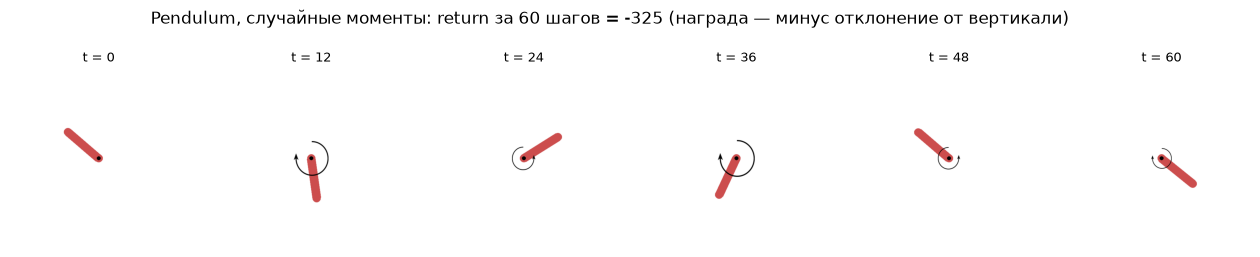

дискретное действие 2 -> [2.] | принадлежит Box? True


In [6]:
pendulum = gym.make("Pendulum-v1", render_mode="rgb_array")
print("действие:", pendulum.action_space, " наблюдение:", pendulum.observation_space)

# Случайная политика: момент выбирается равномерно из Box.
frames, total = rollout_frames(pendulum, lambda obs: pendulum.action_space.sample(), max_steps=60, seed=0)
show_strip(frames, f"Pendulum, случайные моменты: return за 60 шагов = {total:.0f} (награда — минус отклонение от вертикали)", n=6)

# Дискретизация: три уровня момента вместо континуума — так мы поступали с Mountain Car.
levels = np.array([-2.0, 0.0, 2.0], dtype=np.float32)
def discrete_to_torque(k):            # k из Discrete(3) -> действие для Box
    return levels[[k]]
print("дискретное действие 2 ->", discrete_to_torque(2), "| принадлежит Box?", pendulum.action_space.contains(discrete_to_torque(2)))
pendulum.close()

Обратите внимание на награду маятника: она **плотная** — на каждом шаге штраф за отклонение от вертикали, скорость и потраченный момент, все три с разным масштабом. К вопросу о масштабах слагаемых мы сейчас перейдём.

## 5. Награда: разреженная, плотная, shaping и типичные ошибки

Награда — единственный канал, по которому мы объясняем агенту, чего хотим. На прошлой лекции было правило «награда описывает *что*, а не *как*». Сегодня посмотрим, как это правило уживается с практикой.

### 5.1 Разреженная и плотная

![reward](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/reward_types.png)

* **Разреженная** (sparse): почти всегда 0, что-то ненулевое только в конце — «дошёл / не дошёл», «выиграл / проиграл». Честно описывает цель, но пока агент ни разу не дошёл, все эпизоды одинаковы, и учиться не на чем. Мы видели это на Mountain Car.
* **Плотная** (dense): подсказка на каждом шаге — расстояние до цели, скорость, штраф за время. Учиться легко, но теперь агент оптимизирует **подсказку**, а не цель, и может найти способ собирать подсказки, не решая задачу.

### 5.2 Reward shaping

**Shaping** — добавление к настоящей награде вспомогательного слагаемого $F$, которое делает сигнал плотнее:

$$
R'(s, a, s') = R(s, a, s') + F(s, a, s').
$$

Опасность: неудачный $F$ меняет то, что агент считает оптимальным. Классический пример — награда за приближение к цели: агент открывает, что можно бесконечно ходить туда-сюда вокруг цели и собирать «приближения», не заходя в неё.

Есть форма $F$, которая **гарантированно не меняет оптимальную политику** — потенциальный shaping (Ng, Harada, Russell, 1999):

$$
F(s, s') = \gamma\,\Phi(s') - \Phi(s),
$$

где $\Phi(s)$ — любая функция состояния («потенциал», например минус расстояние до цели). Почему работает: на любой траектории эти слагаемые схлопываются в телескопическую сумму, и return меняется на константу $-\Phi(s_0)$, одинаковую для всех траекторий из одного старта. Ходить кругами бесполезно: вернулся в ту же клетку — сумма подсказок обнулилась.

### 5.3 Типичные ошибки

1. **Положительная награда за каждый шаг** («+1 за то, что жив») в задаче, которую нужно закончить: агент учится **не заканчивать** — тянуть время выгоднее, чем дойти до цели. Для CartPole это правильно (цель — продержаться), для лабиринта — катастрофа.
2. **Награда за средство, а не за цель**: «держи угол шеста маленьким» вместо «не урони». Агент найдёт способ держать угол маленьким, необязательно тот, который вы ожидали.
3. **Несбалансированные слагаемые**: штраф за энергию в 100 раз больше награды за прогресс — агент выбирает вообще не двигаться. Всегда смотрите на *масштаб* каждого слагаемого на реальной траектории.
4. **Награда, которую можно получить, ничего не делая**: бонус «за исследование новой клетки», не убывающий со временем, — агент бегает по кругу.
5. **Разные награды при обучении и при оценке** без проверки: обучили на плотной, отчитались по плотной, а по настоящей — ноль.

> **Факт.** Программа Тома Мёрфи (2013), игравшая в NES-игры по счёту, в Tetris научилась ставить игру на паузу перед неизбежным проигрышем: на паузе отрицательная награда никогда не наступает. Десятки похожих историй собраны в подборке DeepMind [«Specification gaming: the flip side of AI ingenuity»](https://deepmind.google/discover/blog/specification-gaming-the-flip-side-of-ai-ingenuity/) и в [таблице Виктории Краковны](https://vkrakovna.wordpress.com/2018/04/02/specification-gaming-examples-in-ai/) — почти все они начинаются с плохо спроектированной награды. Лодка из [CoastRunners](https://openai.com/index/faulty-reward-functions/) с прошлой лекции — оттуда же; систематический обзор есть у [Lilian Weng](https://lilianweng.github.io/posts/2024-11-28-reward-hacking/).

### Самопроверка: найдите ошибку в награде

Три награды, которые выглядят разумно. Что пойдёт не так? Ответы под спойлерами.

**Лабиринт: +1 за каждый шаг, пока агент жив, и +10 за выход.**

<details>
<summary>Разбор</summary>

Ошибка 1. С лимитом в 100 шагов «не выходить» приносит 100, а выход за 20 шагов — 30. Агент научится избегать выхода. Правильно: 0 или −1 за шаг и +10 за выход.

</details>

**Робот-манипулятор: −1 за каждый джоуль энергии и +0.01 за каждый сантиметр приближения к предмету.**

<details>
<summary>Разбор</summary>

Ошибка 3. Штраф за энергию на два порядка больше награды за прогресс: оптимально не двигаться. Слагаемые нужно привести к одному масштабу на реальной траектории — например, посмотреть, сколько энергии тратит хороший ручной контроллер.

</details>

**Исследование карты: +1 каждый раз, когда агент оказывается в клетке, где не был последние 10 шагов.**

<details>
<summary>Разбор</summary>

Ошибка 4. Бонус не убывает: цикл из 11 клеток даёт +1 на каждом шаге вечно. Честный бонус за новизну должен убывать с числом посещений клетки (об этом на неделе про exploration).

</details>

Правило: **обучать можно на плотной награде, но оценивать — только по настоящей.** Ниже, в разделе 8, мы построим среду с разреженной наградой, а в разделе 9 сравним три награды: разреженную, «сломанную» из ошибки 1 и потенциальный shaping — с честной оценкой по настоящей цели.

## 6. Политика: четыре варианта

Политика — то, что мы обучаем. Два независимых выбора:

![policy](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/policy_types.png)

**Детерминированная или стохастическая.** $a = \pi(s)$ выдаёт одно действие; $\pi(a \mid s)$ — распределение. Стохастическая нужна во время обучения (исследование) и в играх с соперником (детерминированного игрока можно «прочитать»). После обучения политику часто делают детерминированной — берут $\arg\max_a \pi(a \mid s)$, хотя мы видели на Frozen Lake, что это не всегда безопасно.

**Табличная или параметрическая.** Таблица $\pi[s, a]$ работает, пока состояний немного, и это всё, что мы использовали до сих пор. Когда состояние — картинка или вектор вещественных чисел, таблицу заменяют функцией с параметрами $\theta$:

$$
\pi_\theta(a \mid s) = \text{softmax}\big(f_\theta(s)\big)_a,
$$

где $f_\theta$ — линейная модель или нейросеть. Обучение сводится к настройке $\theta$ градиентом — как в обычном обучении с учителем. Это неделя 5.

| | Табличная | Параметрическая |
|---|---|---|
| Состояния | конечные, немного | любые |
| Обобщение на невиденные состояния | нет | да |
| Что обучаем | числа в клетках | веса $\theta$ |
| Сегодня | GridWorld, Cross-Entropy | — |

**Эпизодические и непрерывные задачи.** В эпизодической есть конец и `reset()`, в непрерывной — нет, и без $\gamma < 1$ сумма наград бесконечна. Многие «непрерывные» задачи на практике режут на эпизоды искусственно (`TimeLimit`), — и вот тут важна разница `terminated` / `truncated` из прошлой лекции: обрыв по времени не означает, что будущих наград нет.

### Демо: почему детерминированную политику «читают»

Камень-ножницы-бумага против соперника, который запоминает ваш последний ход и играет то, что его бьёт. Детерминированная политика («всегда камень») предсказуема — и проигрывает всё. Случайная политика непредсказуема — и выигрывает треть, как и положено против любого соперника.

In [7]:
BEATS = {0: 1, 1: 2, 2: 0}                     # камень < бумага < ножницы < камень

def play(policy, n_rounds=300, seed=0):
    """policy(rng) -> ход. Соперник играет то, что бьёт наш предыдущий ход. Возвращает долю побед."""
    rng, last, wins = np.random.default_rng(seed), 0, 0
    for _ in range(n_rounds):
        a = policy(rng)
        opponent = BEATS[last]                  # соперник «прочитал» наш прошлый ход
        wins += BEATS[opponent] == a
        last = a
    return wins / n_rounds

print(f"детерминированная («всегда камень»): побед {play(lambda rng: 0):.0%}")
print(f"стохастическая (равномерная)       : побед {play(lambda rng: int(rng.integers(3))):.0%}")

детерминированная («всегда камень»): побед 0%
стохастическая (равномерная)       : побед 31%


Тот же эффект в покере, в StarCraft и в любой игре с соперником, который учится: оптимальная политика там **обязана** быть стохастической. А во время обучения стохастичность нужна всегда — это и есть исследование из прошлой лекции.

## 7. Устройство среды в Gymnasium

[Gymnasium](https://gymnasium.farama.org/) — стандартный интерфейс среды, который понимают все библиотеки RL (документация: [`Env`](https://gymnasium.farama.org/api/env/), [`spaces`](https://gymnasium.farama.org/api/spaces/), [обёртки](https://gymnasium.farama.org/api/wrappers/)). Среда — класс, наследующий `gym.Env`, с двумя атрибутами и двумя методами:

![anatomy](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/env_anatomy.png)

* `observation_space`, `action_space` — **описание формы** наблюдений и действий. Алгоритм по ним понимает, какой размер входа и выхода делать у сети.
* `reset(seed=None)` → `(obs, info)` — начать эпизод. Если передан `seed`, среда инициализирует `self.np_random` — свой генератор случайных чисел, которым должна пользоваться вся случайность внутри среды.
* `step(action)` → `(obs, reward, terminated, truncated, info)` — один шаг. `terminated` — среда пришла в терминальное состояние, `truncated` — эпизод оборван снаружи. `info` — словарь для всего остального (маска действий, диагностика).
* `render()` — картинка или текст для человека; режим задаётся при создании (`render_mode="rgb_array"` возвращает массив пикселей).

Посмотрим на готовую среду изнутри. `gym.make` возвращает не сам класс среды, а **луковицу из обёрток** вокруг него:

In [8]:
env = gym.make("CartPole-v1")
layer = env
while hasattr(layer, "env"):                 # разворачиваем луковицу
    print(type(layer).__name__, end=" -> ")
    layer = layer.env
print(type(layer).__name__, "(это и есть env.unwrapped)")

print("\nspec.max_episode_steps =", env.spec.max_episode_steps)
print("observation_space      =", env.observation_space)
print("action_space           =", env.action_space)

obs, info = env.reset(seed=0)
obs, reward, terminated, truncated, info = env.step(env.action_space.sample())
print("\nstep ->", obs.round(3), reward, terminated, truncated, info)
env.close()

TimeLimit -> OrderEnforcing -> PassiveEnvChecker -> CartPoleEnv (это и есть env.unwrapped)

spec.max_episode_steps = 500
observation_space      = Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
action_space           = Discrete(2)

step -> [ 0.013 -0.217 -0.047  0.23 ] 1.0 False False {}


Три слоя `gym.make` добавляет сам: `PassiveEnvChecker` проверяет типы, `OrderEnforcing` следит, чтобы `step()` не вызывали до `reset()`, `TimeLimit` обрывает эпизод на 500-м шаге с `truncated=True`. Сама физика тележки живёт в `CartPoleEnv` и доступна как `env.unwrapped`. К обёрткам вернёмся в разделе 9 — а сейчас напишем свою среду.

## 8. Строим свою среду: GridWorld с препятствиями

Задача: сетка, стены, старт и цель. Агент ходит в четыре стороны, с вероятностью `slip` его «заносит» в случайную сторону. Награда — 1 за приход в цель, иначе 0 (разреженная, как в Frozen Lake). Состояние — номер клетки.

Проектные решения, которые мы принимаем прямо сейчас (в домашнем задании их будете принимать вы):

| Вопрос | Наше решение | Альтернатива |
|---|---|---|
| Что такое состояние? | номер клетки, `Discrete(rows*cols)` | координаты `Box`, картинка |
| Что такое действие? | `Discrete(4)` | `MultiDiscrete` (направление + сколько шагов) |
| Где случайность? | `slip`: действие заменяется случайным | случайное появление стен, ветер |
| Когда конец? | пришли в цель → `terminated` | лимит шагов → `truncated` (добавим обёрткой) |
| Какая награда? | разреженная: 1 в цели | плотная (добавим обёрткой) |

Карта задаётся строками: `S` — старт, `G` — цель, `#` — стена, `.` — пол.

In [9]:
class GridWorldEnv(gym.Env):
    """Сетка с препятствиями. Агент идёт от S к G; с вероятностью slip действие заменяется случайным."""

    metadata = {"render_modes": ["ansi", "rgb_array"], "render_fps": 4}
    MOVES = {0: (0, -1), 1: (1, 0), 2: (0, 1), 3: (-1, 0)}   # ←, ↓, →, ↑  как (dr, dc)
    ARROWS = "←↓→↑"

    DEFAULT_LAYOUT = [
        "S....#",
        ".##..#",
        "...#..",
        ".#..#.",
        ".#.#..",
        "....#G",
    ]

    def __init__(self, layout=None, slip=0.0, render_mode=None):
        self.layout = [list(row) for row in (layout or self.DEFAULT_LAYOUT)]
        self.n_rows, self.n_cols = len(self.layout), len(self.layout[0])
        self.slip = slip
        self.render_mode = render_mode

        self.observation_space = spaces.Discrete(self.n_rows * self.n_cols)
        self.action_space = spaces.Discrete(4)

        self.start = self._find("S")
        self.goal = self._find("G")
        self.pos = self.start

    def _find(self, char):
        for r, row in enumerate(self.layout):
            for c, cell in enumerate(row):
                if cell == char:
                    return (r, c)
        raise ValueError(f"на карте нет клетки {char!r}")

    def _obs(self):
        return self.pos[0] * self.n_cols + self.pos[1]        # номер клетки

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)              # инициализирует self.np_random
        self.pos = self.start
        return self._obs(), {"action_mask": self._action_mask()}

    def step(self, action):
        if self.slip > 0 and self.np_random.random() < self.slip:
            action = int(self.np_random.integers(4))         # поскользнулись
        dr, dc = self.MOVES[int(action)]
        r, c = self.pos[0] + dr, self.pos[1] + dc
        if 0 <= r < self.n_rows and 0 <= c < self.n_cols and self.layout[r][c] != "#":
            self.pos = (r, c)                                 # иначе упёрлись в стену
        terminated = self.pos == self.goal
        reward = 1.0 if terminated else 0.0
        return self._obs(), reward, terminated, False, {"action_mask": self._action_mask()}

    def _action_mask(self):
        """Какие из 4 действий не упираются в стену или границу (маска действий, раздел 4)."""
        mask = np.zeros(4, dtype=bool)
        for a, (dr, dc) in self.MOVES.items():
            r, c = self.pos[0] + dr, self.pos[1] + dc
            mask[a] = 0 <= r < self.n_rows and 0 <= c < self.n_cols and self.layout[r][c] != "#"
        return mask

    def render(self):
        if self.render_mode == "ansi":
            rows = []
            for r, row in enumerate(self.layout):
                rows.append("".join("A" if (r, c) == self.pos else ch for c, ch in enumerate(row)))
            return "\n".join(rows)
        if self.render_mode == "rgb_array":
            return self._render_rgb()

    def _render_rgb(self):
        colors = {".": "#f4f4f4", "#": "#555555", "S": "#cfe3f7", "G": "#a9dfa9"}
        fig, ax = plt.subplots(figsize=(2.6, 2.6 * self.n_rows / self.n_cols))
        for r, row in enumerate(self.layout):
            for c, ch in enumerate(row):
                ax.add_patch(plt.Rectangle((c, r), 1, 1, color=colors[ch], ec="white"))
        ax.add_patch(plt.Circle((self.pos[1] + 0.5, self.pos[0] + 0.5), 0.3, color="#4C72B0"))
        ax.set_xlim(0, self.n_cols); ax.set_ylim(self.n_rows, 0); ax.set_aspect("equal"); ax.axis("off")
        fig.tight_layout(pad=0)
        fig.canvas.draw()
        img = np.asarray(fig.canvas.buffer_rgba())[:, :, :3].copy()
        plt.close(fig)
        return img

In [10]:
env = GridWorldEnv(render_mode="ansi")
obs, info = env.reset(seed=0)
print("наблюдение:", obs, " пространство:", env.observation_space, env.action_space)
print("маска действий на старте (←, ↓, →, ↑):", info["action_mask"])
print(env.render())

# Первое, что делают с новой средой — прогоняют проверку интерфейса.
from gymnasium.utils.env_checker import check_env
check_env(GridWorldEnv())
print("\ncheck_env: ошибок нет")

наблюдение: 0  пространство: Discrete(36) Discrete(4)
маска действий на старте (←, ↓, →, ↑): [False  True  True False]
A....#
.##..#
...#..
.#..#.
.#.#..
....#G

check_env: ошибок нет


/usr/local/lib/python3.11/dist-packages/gymnasium/utils/env_checker.py:440: UserWarning: WARN: Not able to test alternative render modes due to the environment not having a spec. Try instantiating the environment through `gymnasium.make`
  logger.warn(


`check_env` проверяет, что `reset` и `step` возвращают то, что обещают пространства, что `seed` действительно делает среду воспроизводимой, что `render` не падает. Это дешёвая страховка от самых обидных багов — например, когда `step` возвращает `numpy.int64` там, где обещан `int`, и алгоритм падает через час обучения.

Теперь картинка вместо текста и случайный агент.

случайный агент: 40 шагов, return 0.0


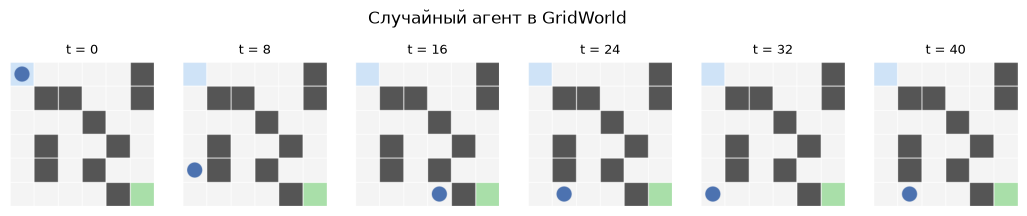

In [11]:
env = GridWorldEnv(render_mode="rgb_array")
frames, total = rollout_frames(env, lambda obs: env.action_space.sample(), max_steps=40, seed=0)
print(f"случайный агент: {len(frames) - 1} шагов, return {total}")
show_strip(frames, "Случайный агент в GridWorld", n=6, width=13)
show_frames(frames, "Случайный агент в GridWorld")

### Маска действий в пять строк

Половина случайных шагов выше — удары в стену. Среда уже кладёт в `info["action_mask"]` допустимые действия; агенту остаётся сэмплировать только из них.

In [12]:
def masked_random_policy(mask, rng):
    """Случайное действие среди допустимых."""
    return int(rng.choice(np.flatnonzero(mask)))

rng = np.random.default_rng(0)
env = GridWorldEnv()
obs, info = env.reset(seed=0)
bumps, steps = 0, 0
for _ in range(200):
    before = obs
    obs, r, terminated, truncated, info = env.step(masked_random_policy(info["action_mask"], rng))
    bumps += obs == before; steps += 1
    if terminated:
        obs, info = env.reset()
print(f"замаскированный случайный агент: {steps} шагов, ударов в стену: {bumps}")

замаскированный случайный агент: 200 шагов, ударов в стену: 0


### Учим агента на своей среде

Алгоритм из недели 1 не знает, что среда наша: ему нужны только `reset`, `step` и размеры пространств. Скопируем его без изменений.

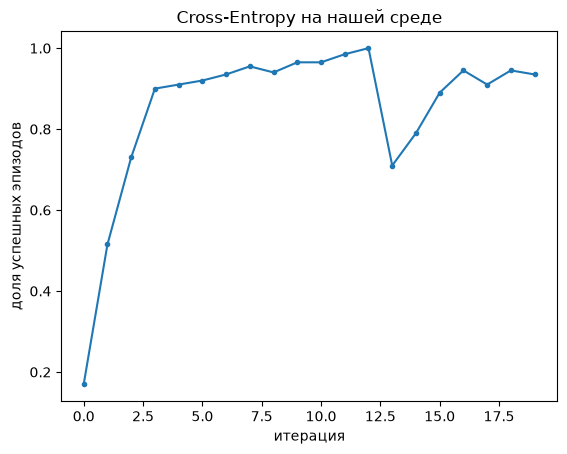

выученная политика (самое вероятное действие):
  → → → ↓ ↓ #
  ↑ # # → ↓ #
  ↑ ← ← # → ↓
  ↑ # ↑ → # ↓
  ↑ # ← # → ↓
  ↑ ↓ ← ← # G


In [13]:
def run_session(env, policy, rng, max_steps=100):
    """Один эпизод политикой-таблицей: состояния, действия, суммарная награда."""
    obs, _ = env.reset(seed=int(rng.integers(1_000_000)))
    states, actions, total = [], [], 0.0
    for _ in range(max_steps):
        a = int(rng.choice(policy.shape[1], p=policy[obs]))
        states.append(obs); actions.append(a)
        obs, r, terminated, truncated, _ = env.step(a)
        total += r
        if terminated or truncated:
            break
    return states, actions, total


def cross_entropy_method(env, n_iter=25, n_sessions=200, q=0.7, laplace=0.5, mix=0.5,
                         seed=0, max_steps=100, evaluate=None):
    """Табличный Cross-Entropy из лекции 1. evaluate(policy) -> число, если хотим отдельную метрику."""
    rng = np.random.default_rng(seed)
    n_states, n_actions = env.observation_space.n, env.action_space.n
    policy = np.ones((n_states, n_actions)) / n_actions
    log = {"mean": [], "eval": []}
    for it in range(n_iter):
        sessions = [run_session(env, policy, rng, max_steps) for _ in range(n_sessions)]
        returns = np.array([G for _, _, G in sessions])
        threshold = np.quantile(returns, q)
        elite = [s for s in sessions if s[2] >= threshold and s[2] > returns.min()]
        counts = np.full((n_states, n_actions), laplace)
        for states, actions, _ in elite:
            for s, a in zip(states, actions):
                counts[s, a] += 1
        new_policy = policy.copy()
        seen = counts.sum(axis=1) > 0
        new_policy[seen] = counts[seen] / counts[seen].sum(axis=1, keepdims=True)
        policy = mix * new_policy + (1 - mix) * policy
        log["mean"].append(returns.mean())
        if evaluate is not None:
            log["eval"].append(evaluate(policy))
    return policy, log


env = GridWorldEnv()
policy, log = cross_entropy_method(env, n_iter=20, n_sessions=200)

plt.plot(log["mean"], marker=".")
plt.xlabel("итерация"); plt.ylabel("доля успешных эпизодов")
plt.title("Cross-Entropy на нашей среде"); plt.show()

print("выученная политика (самое вероятное действие):")
show_policy(env, policy)

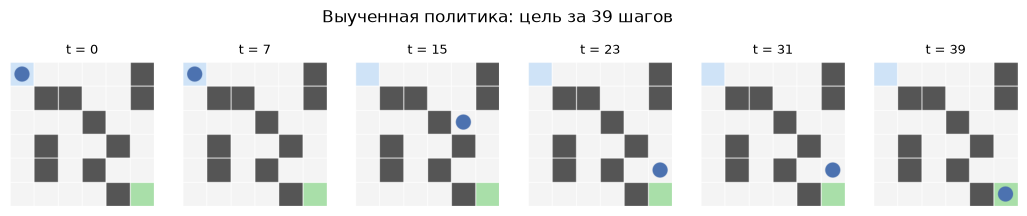

In [14]:
# Эпизод выученной политикой, действия — случайно из pi(.|s).
rng = np.random.default_rng(1)
env = GridWorldEnv(render_mode="rgb_array")
frames, total = rollout_frames(env, lambda obs: int(rng.choice(4, p=policy[obs])), max_steps=50, seed=0)
show_strip(frames, f"Выученная политика: цель за {len(frames) - 1} шагов", n=6, width=13)
show_frames(frames, f"Выученная политика: цель за {len(frames) - 1} шагов")

Тридцать строк — и у нас среда, на которой работает настоящий RL-алгоритм. Всё, что мы дальше будем делать с этой средой, — менять её поведение, **не трогая класс**.

## 9. Обёртки: изменяем среду, не трогая её код

![onion](https://raw.githubusercontent.com/IlyaChichkanov/Reinforcement-learning/main/assets/wrapper_onion.png)

**Обёртка** (wrapper) — объект, который выглядит как среда, но внутри держит другую среду и что-то меняет по дороге: подменяет наблюдение, награду, действие или следит за эпизодами. Обёртки можно вкладывать друг в друга; `env.unwrapped` всегда даёт самую внутреннюю среду.

Готовые обёртки, которые понадобятся чаще всего:

| Обёртка | Что делает |
|---|---|
| `TimeLimit(env, max_episode_steps)` | обрывает эпизод, `truncated=True` |
| `RecordEpisodeStatistics(env)` | в конце эпизода кладёт в `info["episode"]` return и длину |
| `TransformReward(env, f)` / `TransformObservation` | применяет функцию к награде / наблюдению |
| `NormalizeObservation`, `NormalizeReward` | бегущая нормализация — важно для нейросетей |
| `FrameStackObservation(env, k)` | стек последних $k$ наблюдений — лекарство от POMDP из раздела 3 |
| `RescaleAction`, `ClipAction` | приводит непрерывные действия к диапазону среды |

Свою обёртку пишут, наследуя `gym.Wrapper` (общий случай) или `gym.RewardWrapper` / `gym.ObservationWrapper` / `gym.ActionWrapper` (переопределить один метод). Сделаем три: лимит шагов из коробки, «сломанную» награду из ошибки 1 и **потенциальный shaping** своими руками.

In [15]:
from gymnasium.wrappers import TimeLimit, RecordEpisodeStatistics

class StepBonus(gym.RewardWrapper):
    """Ошибка 1 из раздела 5: «+0.1 за каждый шаг, пока жив». Один метод — reward()."""

    def __init__(self, env, bonus=0.1):
        super().__init__(env)
        self.bonus = bonus

    def reward(self, r):
        return r + self.bonus


class PotentialShaping(gym.Wrapper):
    """Плотная награда: R' = R + gamma * Phi(s') - Phi(s), Phi = -расстояние до цели / scale."""

    def __init__(self, env, gamma=0.99, scale=10.0, step_penalty=0.01):
        super().__init__(env)
        self.gamma, self.scale, self.step_penalty = gamma, scale, step_penalty

    def _phi(self, obs):
        r, c = divmod(int(obs), self.unwrapped.n_cols)
        gr, gc = self.unwrapped.goal
        return -(abs(r - gr) + abs(c - gc)) / self.scale

    def step(self, action):
        phi_before = self._phi(self.unwrapped._obs())
        obs, reward, terminated, truncated, info = self.env.step(action)
        info["true_reward"] = reward                       # настоящую награду сохраняем
        shaped = reward - self.step_penalty + self.gamma * self._phi(obs) - phi_before
        return obs, shaped, terminated, truncated, info


env = RecordEpisodeStatistics(TimeLimit(PotentialShaping(GridWorldEnv()), max_episode_steps=30))
obs, _ = env.reset(seed=0)
while True:
    obs, r, terminated, truncated, info = env.step(env.action_space.sample())
    if terminated or truncated:
        break
print("эпизод закончился:", "terminated" if terminated else "truncated (лимит 30 шагов)")
print("статистика из info['episode']:", {k: float(v) for k, v in info["episode"].items()})
print("самая внутренняя среда:", type(env.unwrapped).__name__)

эпизод закончился: truncated (лимит 30 шагов)
статистика из info['episode']: {'r': 0.22199999999999998, 'l': 30.0, 't': 0.00036}
самая внутренняя среда: GridWorldEnv


### Эксперимент: три награды и одна ловушка

Возьмём карту побольше и жёсткий лимит в 30 шагов: случайный агент почти никогда не успевает дойти. Обучим Cross-Entropy на трёх версиях награды:

1. **разреженная** — 1 в цели, иначе 0 (настоящая цель);
2. **«живи дольше»** — та же плюс 0.1 за каждый шаг (`StepBonus`);
3. **потенциальный shaping** — та же плюс $\gamma\Phi(s') - \Phi(s)$ и небольшой штраф за шаг (`PotentialShaping`).

**Оценивать** все три политики будем честно — долей эпизодов, в которых агент дошёл до цели, без подсказок и бонусов.

случайная политика доходит до цели за 30 шагов в 0.0% эпизодов


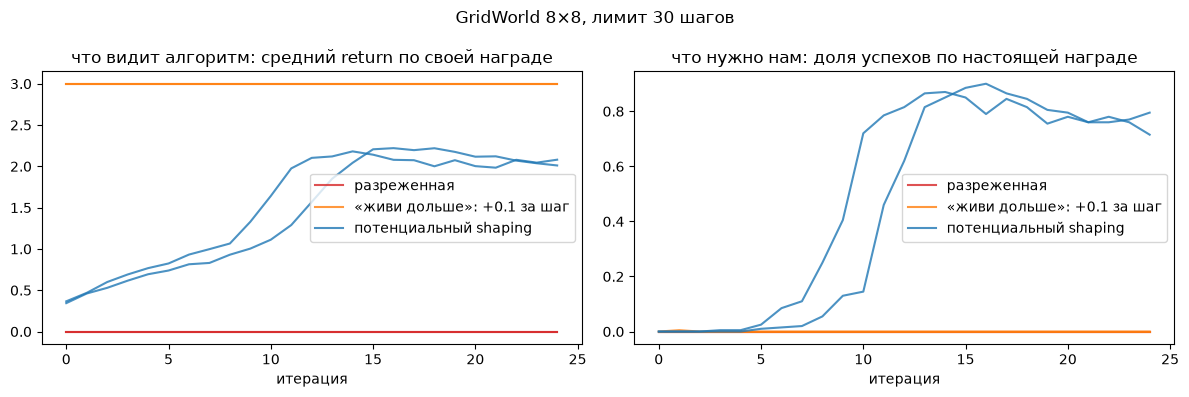

In [16]:
BIG_LAYOUT = [
    "S.......",
    ".####.#.",
    ".#....#.",
    ".#.##.#.",
    ".#.#..#.",
    ".#.#.##.",
    "...#....",
    "##.#.##G",
]

T = 30
eval_env = TimeLimit(GridWorldEnv(layout=BIG_LAYOUT), max_episode_steps=T)
eval_rng = np.random.default_rng(123)

def true_success(policy, n=200):
    """Доля эпизодов, где агент дошёл до цели, — настоящая цель задачи."""
    return np.mean([run_session(eval_env, policy, eval_rng, max_steps=T + 1)[2] for _ in range(n)])

uniform = np.ones((eval_env.observation_space.n, 4)) / 4
print(f"случайная политика доходит до цели за {T} шагов в {true_success(uniform, 500):.1%} эпизодов")

variants = {
    "разреженная":                   (lambda: TimeLimit(GridWorldEnv(layout=BIG_LAYOUT), max_episode_steps=T), "C3"),
    "«живи дольше»: +0.1 за шаг":    (lambda: TimeLimit(StepBonus(GridWorldEnv(layout=BIG_LAYOUT)), max_episode_steps=T), "C1"),
    "потенциальный shaping":         (lambda: TimeLimit(PotentialShaping(GridWorldEnv(layout=BIG_LAYOUT)), max_episode_steps=T), "C0"),
}
policies = {}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, (make_env, color) in variants.items():
    for seed in range(2):
        policies[label], log = cross_entropy_method(make_env(), n_iter=25, n_sessions=200, seed=seed,
                                                    max_steps=T + 1, evaluate=true_success)
        axes[0].plot(log["mean"], color=color, alpha=0.8, label=label if seed == 0 else None)
        axes[1].plot(log["eval"], color=color, alpha=0.8, label=label if seed == 0 else None)
axes[0].set_title("что видит алгоритм: средний return по своей награде")
axes[1].set_title("что нужно нам: доля успехов по настоящей награде")
for ax in axes:
    ax.set_xlabel("итерация"); ax.legend()
plt.suptitle(f"GridWorld 8×8, лимит {T} шагов"); plt.tight_layout(); plt.show()

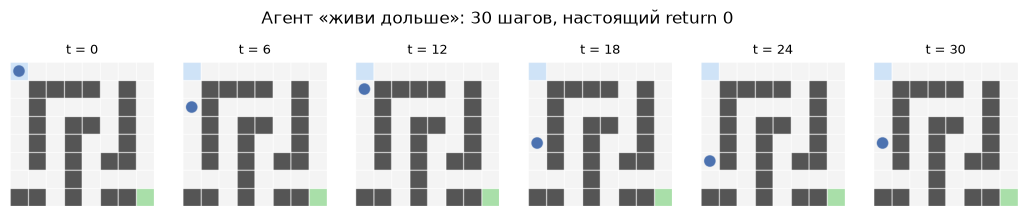

In [17]:
# Что именно выучил агент с наградой «живи дольше»: эпизод по настоящей среде.
rng = np.random.default_rng(1)
env = TimeLimit(GridWorldEnv(layout=BIG_LAYOUT, render_mode="rgb_array"), max_episode_steps=T)
pol = policies["«живи дольше»: +0.1 за шаг"]
frames, total = rollout_frames(env, lambda obs: int(rng.choice(4, p=pol[obs])), max_steps=T, seed=0)
show_strip(frames, f"Агент «живи дольше»: {len(frames) - 1} шагов, настоящий return {total:.0f}", n=6, width=13)
show_frames(frames, "Агент «живи дольше» гуляет и не собирается к цели")

Три сюжета на одном графике:

* **Разреженная**: обучение не начинается вовсе — за 30 шагов случайный агент до цели не доходит, элита пуста, левый и правый графики одинаково лежат на нуле.
* **«Живи дольше»**: слева алгоритм счастлив — return растёт до максимума 3.0 (30 шагов × 0.1). Справа ноль: дойти до цели значит **закончить эпизод и перестать получать бонус**, и агент учится гулять, а не доходить. Награда честно оптимизирована; неправильно была поставлена задача.
* **Потенциальный shaping**: агент доходит в трёх четвертях эпизодов, и это измерено по настоящей цели. Подсказка помогла найти дорогу, но не подменила цель — в точности то, что обещает теорема Ng, Harada и Russell.

Общий урок: **смотрите на правый график, а не на левый.** Кривая обучения по своей награде говорит только о том, что алгоритм что-то оптимизирует; о чём именно — знает только оценка по настоящей награде.

**📖 Дома**: поднимите лимит до 50 шагов и повторите. Разреженная награда начнёт работать (успехи у случайного агента появляются), а плотная выйдет на плато ниже неё. Shaping не меняет *оптимальную* политику, но меняет то, какие эпизоды Cross-Entropy считает элитными, — и это уже свойство алгоритма, а не награды. Подумайте, почему, и проверьте гипотезу, отключив `step_penalty`.

### Обёртка над наблюдением: делаем свою среду частично наблюдаемой (⏱ если есть время)

В разделе 3 мы отнимали у CartPole скорость. Сделаем то же с GridWorld: пусть агент видит не номер клетки, а только **какие из четырёх соседних клеток проходимы** — как робот с четырьмя датчиками касания. Наблюдений всего 16, и многие клетки выглядят одинаково.

Карта-«змейка»: в верхнем коридоре нужно идти вправо, в нижнем — влево, а выглядят они для агента абсолютно одинаково (стена сверху, стена снизу, свободно слева и справа).

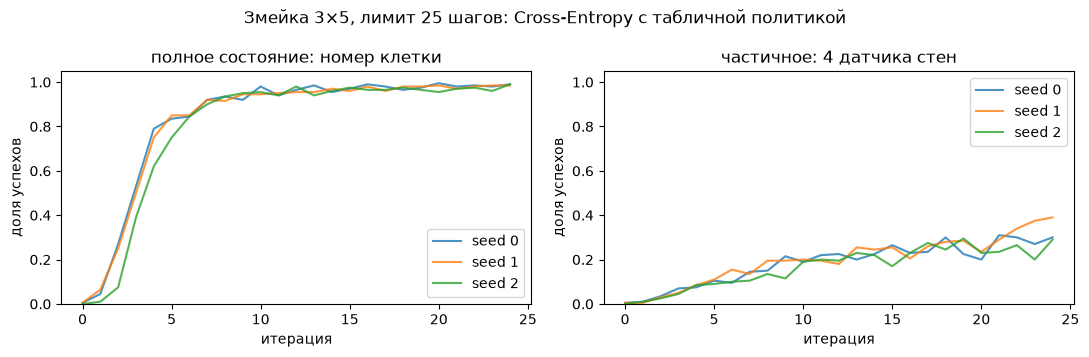

наблюдение в клетке (0, 2) верхнего коридора: 5  в клетке (2, 2) нижнего: 5  <- одинаковые, а действия нужны разные


In [18]:
class LocalView(gym.ObservationWrapper):
    """Наблюдение — битовая маска «проходим ли сосед» по 4 направлениям: Discrete(16) вместо номера клетки."""

    def __init__(self, env):
        super().__init__(env)
        self.observation_space = spaces.Discrete(16)

    def observation(self, obs):
        u = self.unwrapped
        r, c = divmod(int(obs), u.n_cols)
        code = 0
        for a, (dr, dc) in u.MOVES.items():
            rr, cc = r + dr, c + dc
            if 0 <= rr < u.n_rows and 0 <= cc < u.n_cols and u.layout[rr][cc] != "#":
                code |= 1 << a
        return code

SNAKE = ["S....",
         "####.",
         "G...."]
T_SNAKE = 25

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, (label, wrap) in zip(axes, [("полное состояние: номер клетки", lambda e: e),
                                    ("частичное: 4 датчика стен", LocalView)]):
    for seed in range(3):
        env = TimeLimit(wrap(GridWorldEnv(layout=SNAKE)), max_episode_steps=T_SNAKE)
        pol, log = cross_entropy_method(env, n_iter=25, n_sessions=200, seed=seed, max_steps=T_SNAKE + 1)
        ax.plot(log["mean"], alpha=0.8, label=f"seed {seed}")
    ax.set_title(label); ax.set_xlabel("итерация"); ax.set_ylabel("доля успехов"); ax.set_ylim(0, 1.05); ax.legend()
plt.suptitle(f"Змейка 3×5, лимит {T_SNAKE} шагов: Cross-Entropy с табличной политикой"); plt.tight_layout(); plt.show()

env = LocalView(GridWorldEnv(layout=SNAKE))
env.reset(seed=0)
print("наблюдение в клетке (0, 2) верхнего коридора:", env.observation(0 * 5 + 2),
      " в клетке (2, 2) нижнего:", env.observation(2 * 5 + 2), " <- одинаковые, а действия нужны разные")

Табличная политика по такому наблюдению **не может** различить два коридора: в одной строке таблицы ей нужно и «вправо», и «влево», и лучшее, что она находит, — ходить наугад. Среда та же, задача та же, алгоритм тот же; сломалось только наблюдение. Лекарства те же, что для CartPole: добавить историю (последние действия) или дать агенту память.

**📖 Дома. Наблюдение для нейросети.** Номер клетки — плохой вход для нейросети (клетка 5 не «в пять раз больше» клетки 1). Стандартный ход — one-hot-вектор, и это тоже обёртка: `TransformObservation(env, lambda s: np.eye(n)[s], Box(0, 1, (n,)))`. Понадобится на неделе 5.

## 10. Воспроизводимость, векторные среды, регистрация

### Сиды

В RL три источника случайности, и у каждого свой генератор: **среда** (`env.reset(seed=...)` → `env.np_random`), **агент** (`np.random.default_rng(seed)` для выбора действий) и **пространства** (`env.action_space.seed(...)` для `sample()`). Эксперимент воспроизводим, только если зафиксированы все три — и он всё равно **не** воспроизводим между версиями библиотек и железом, если в деле нейросети на GPU. Практическое правило: любой график в отчёте — среднее по нескольким сидам, а не один запуск.

### Векторные среды

Один вызов `step()` — один шаг одной среды. Чтобы собирать опыт быстрее, запускают $n$ копий среды и делают шаг во всех сразу: `gym.make_vec`. Наблюдения приходят массивом формы `(n, ...)`, действия тоже подаются массивом. Так устроен сбор данных во всех deep-RL-библиотеках ([документация](https://gymnasium.farama.org/api/vector/)), и с недели 5 мы будем пользоваться этим постоянно.

> **Факт.** В симуляторах на GPU ([Isaac Gym](https://arxiv.org/abs/2108.10470), Brax, MJX) параллельно живут **тысячи** копий среды, и робот-гуманоид учится ходить за минуты вместо дней: узкое место RL — не сеть, а сбор опыта.

In [19]:
import time

# Воспроизводимость: два запуска с одним сидом дают одинаковые траектории.
def rollout(seed):
    env = GridWorldEnv(slip=0.3)
    rng = np.random.default_rng(seed)
    obs, _ = env.reset(seed=seed)
    path = [obs]
    for _ in range(15):
        obs, *_ = env.step(int(rng.integers(4)))
        path.append(obs)
    return path
print("seed=7 дважды одинаково:", rollout(7) == rollout(7), "  seed=7 vs seed=8:", rollout(7) == rollout(8))

# Векторная среда: 8 копий CartPole делают шаг одновременно.
venv = gym.make_vec("CartPole-v1", num_envs=8, vectorization_mode="sync")
obs, _ = venv.reset(seed=0)
print("\nформа наблюдения:", obs.shape, " действий:", venv.action_space)
t0 = time.time()
for _ in range(500):
    obs, rewards, terminated, truncated, info = venv.step(venv.action_space.sample())
print(f"8 сред × 500 шагов за {time.time() - t0:.2f} с; награды за последний шаг: {rewards}")
venv.close()

seed=7 дважды одинаково: True   seed=7 vs seed=8: False

форма наблюдения: (8, 4)  действий: MultiDiscrete([2 2 2 2 2 2 2 2])
8 сред × 500 шагов за 0.06 с; награды за последний шаг: [1. 1. 1. 1. 1. 1. 1. 1.]


Тонкость векторных сред: эпизоды в копиях заканчиваются в разное время, и среда **сама** делает `reset` закончившейся копии на следующем шаге. Поэтому флаги `terminated` / `truncated` нужно читать внимательно — это источник половины багов в самописных PPO.

### Регистрация

Чтобы своя среда создавалась через `gym.make("...")` — как встроенные, с `TimeLimit` и проверками, — её регистрируют по имени:

In [20]:
gym.register(id="GridWorld-v0", entry_point=GridWorldEnv, max_episode_steps=50)

env = gym.make("GridWorld-v0", slip=0.1, render_mode="ansi")
obs, _ = env.reset(seed=0)
print(type(env).__name__, "->", type(env.unwrapped).__name__, "| лимит шагов:", env.spec.max_episode_steps)
print(env.render())

TimeLimit -> GridWorldEnv | лимит шагов: 50
A....#
.##..#
...#..
.#..#.
.#.#..
....#G


## 11. Зоопарк сред: куда идти за задачами (📖 дома)

Свою среду писать нужно не всегда: для большинства учебных и исследовательских задач уже есть готовые, с тем же интерфейсом `reset`/`step`. Ориентир на семестр и на выбор темы проекта; в каждой ссылке есть гифки.

| Коллекция | Что внутри | Наблюдение / действие | Когда пригодится |
|---|---|---|---|
| [Gymnasium: Toy Text](https://gymnasium.farama.org/environments/toy_text/) | Frozen Lake, Taxi, Cliff Walking, Blackjack | номер состояния / `Discrete` | недели 1–4: табличные методы |
| [Gymnasium: Classic Control](https://gymnasium.farama.org/environments/classic_control/) | CartPole, Mountain Car, Pendulum, Acrobot | вектор чисел / `Discrete` или `Box` | недели 4–8 |
| [Gymnasium: Box2D](https://gymnasium.farama.org/environments/box2d/) | LunarLander, BipedalWalker, CarRacing | вектор или пиксели / оба типа | недели 6–10 |
| [Gymnasium: MuJoCo](https://gymnasium.farama.org/environments/mujoco/) | HalfCheetah, Hopper, Humanoid, Ant | углы и скорости суставов / `Box` | непрерывное управление, недели 9–10 |
| [ALE: Atari](https://ale.farama.org/) | 57 игр Atari 2600 | пиксели (стек кадров) / `Discrete(18)` | DQN, неделя 6 |
| [MiniGrid](https://minigrid.farama.org/) | процедурные клеточные миры с ключами, дверями, инструкциями | локальный вид / `Discrete` | exploration, иерархический RL |
| [Procgen](https://github.com/openai/procgen) | 16 аркад с процедурной генерацией уровней | пиксели / `Discrete` | обобщение на новые уровни |
| [highway-env](https://highway-env.farama.org/) | вождение: шоссе, парковка, перекрёстки | признаки машин / оба типа | проекты про автономное вождение |
| [PettingZoo](https://pettingzoo.farama.org/) | многоагентные среды: от «камень-ножницы» до футбола | по агенту / по агенту | неделя 15 |
| [Isaac Lab](https://isaac-sim.github.io/IsaacLab/) / [Brax](https://github.com/google/brax) | тысячи роботов параллельно на GPU | `Box` / `Box` | sim-to-real, большие проекты |
| [Craftax](https://github.com/MichaelTMatthews/Craftax) / [MineRL](https://minerl.io/) | выживание в стиле Minecraft | пиксели или символы / составное | долгие горизонты, иерархии |
| [TextWorld](https://github.com/microsoft/TextWorld) | текстовые квесты | текст / текст | RL для языковых агентов |

Как выбирать: сначала самая простая среда, на которой видна суть задачи (для нового алгоритма — CartPole и Frozen Lake), потом усложнять. Алгоритм, который не работает на CartPole, не заработает и на Humanoid.

## 12. Итоги

1. **Граница агент/среда — проектное решение.** Агент — то, что мы обучаем; соперник, тело робота, интерфейс и награда — среда.
2. **Наблюдение должно содержать всё, от чего зависит решение.** Если среда частично наблюдаема, добавьте историю (`FrameStackObservation`) или память; мы дважды видели, как одно и то же наблюдение для разных состояний ломает политику.
3. **Действие — то, чем вы реально управляете.** Дискретное, непрерывное или составное; недопустимые действия отсекает маска.
4. **Награда — это цель, а не подсказка.** Плотная награда и shaping ускоряют обучение, потенциальный shaping $\gamma\Phi(s') - \Phi(s)$ делает это безопасно, а «+0.1 за шаг» учит агента не заканчивать. Оценивать политику можно только по настоящей награде.
5. **Детерминированную политику читают.** Против соперника и во время обучения политика должна быть стохастической.
6. **Среда в Gymnasium — это два пространства и два метода.** `check_env` — обязательный первый тест; обёртки меняют поведение среды, не трогая её код; `gym.register` делает свою среду неотличимой от встроенных.

Словарь: **наблюдение и состояние, POMDP, стек кадров, маска действий, разреженная и плотная награда, shaping, потенциальная функция, reward hacking, табличная и параметрическая политика, `gym.Env`, `spaces`, `terminated`/`truncated`, обёртка, векторная среда, сид**.

## Литература

* [Gymnasium: Basic Usage](https://gymnasium.farama.org/introduction/basic_usage/) и [Make your own custom environment](https://gymnasium.farama.org/introduction/create_custom_env/) — официальный туториал, повторяющий раздел 8.
* A. Ng, D. Harada, S. Russell. [Policy invariance under reward transformations](https://people.eecs.berkeley.edu/~pabbeel/cs287-fa09/readings/NgHaradaRussell-shaping-ICML1999.pdf) (ICML 1999) — потенциальный shaping.
* R. Sutton, A. Barto. *Reinforcement Learning: An Introduction*, глава 3 (агент–среда, награда, эпизодические и непрерывные задачи) и раздел 17.4 про проектирование награды.
* Mnih et al. [Human-level control through deep RL](https://www.nature.com/articles/nature14236) (Nature 2015) — стек из четырёх кадров как лекарство от частичной наблюдаемости в Atari.
* OpenAI. [Dota 2 with Large Scale Deep RL](https://arxiv.org/abs/1912.06680) — как устроены наблюдение, составное действие и маска в большой игре.
* Makoviychuk et al. [Isaac Gym](https://arxiv.org/abs/2108.10470) — тысячи сред на одном GPU.
* DeepMind. [Specification gaming: the flip side of AI ingenuity](https://deepmind.google/discover/blog/specification-gaming-the-flip-side-of-ai-ingenuity/) — коллекция ошибок в награде.

## На семинаре и дома

* Семинар (`../seminar/seminar.ipynb`): пишем GridWorld с нуля по шагам, `check_env`, ручной агент и маска действий, свои обёртки (`StepPenalty`, `PotentialShaping`), ловушка наивного shaping, POMDP на CartPole и стек кадров, Cross-Entropy на своей среде и на скользкой версии.
* ДЗ (`../homework/homework.ipynb`): своя среда «управление запасами» как `gym.Env`, две версии награды и сравнение обучения, формальное описание среды как MDP; бонус — скрытый день недели и наблюдение, которое его чинит.